# Stock Market Unsupervised Clustering Using K-Means

This notebook applies unsupervised machine learning to group selected stocks based on their daily return behavior. Instead of using static CSV files, historical stock data is directly extracted using `yfinance`, making the workflow more dynamic and closer to real-world financial analysis.


In [1]:
pip install yfinance

## 1. Core Libraries

The required Python libraries are imported for numerical computation, data handling, visualization, stock data extraction, preprocessing, clustering, dimensionality reduction, and model evaluation.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import datetime as dt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

import yfinance as yf

## 2. Stock Selection

A custom list of stock tickers is selected for analysis. The tickers include technology, finance, consumer, travel, and automobile-related companies so that clustering can compare different market behavior patterns.


In [4]:
company_tickers = [
    "AAPL", "AMGN", "AMZN", "AXP", "BA", "CAT", "CRM", "CSCO", "CVX", "DIS",
    "GS", "HD", "HON", "IBM", "JNJ", "JPM", "KO", "MCD", "MMM", "MRK",
    "MSFT", "NKE", "NVDA", "PG", "SHW", "TRV", "UNH", "V", "VZ", "WMT"
]

company_tickers = sorted(company_tickers)

print(f"Total companies selected: {len(company_tickers)}")
company_tickers

Total companies selected: 30


['AAPL',
 'AMGN',
 'AMZN',
 'AXP',
 'BA',
 'CAT',
 'CRM',
 'CSCO',
 'CVX',
 'DIS',
 'GS',
 'HD',
 'HON',
 'IBM',
 'JNJ',
 'JPM',
 'KO',
 'MCD',
 'MMM',
 'MRK',
 'MSFT',
 'NKE',
 'NVDA',
 'PG',
 'SHW',
 'TRV',
 'UNH',
 'V',
 'VZ',
 'WMT']

In [5]:
company_tickers = ['AAPL', 'META', 'NVDA', 'TSLA', 'ABBV', 'MCD', 'CCL', 'MSFT', 'GS', 'JPM']
company_tickers = sorted(company_tickers)
company_tickers

['AAPL', 'ABBV', 'CCL', 'GS', 'JPM', 'MCD', 'META', 'MSFT', 'NVDA', 'TSLA']

## 3. Time Period Selection

The analysis uses recent historical stock data. A fixed lookback period is selected so that the stocks are compared over the same market window.


In [6]:
end = dt.datetime.now()
start = end - dt.timedelta(days=365 * 2)

print("Start date:", start.date())
print("End date:", end.date())

Start date: 2024-05-14
End date: 2026-05-14


## 4. Direct Data Extraction Using yfinance

Historical stock data is downloaded directly from Yahoo Finance using `yfinance`. This is different from a CSV-based workflow because the data is fetched dynamically inside the notebook.


In [7]:
df = yf.download(
    tickers=company_tickers,
    start=start,
    end=end
)

df.head()

/tmp/ipykernel_40950/889124320.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  10 of 10 completed


Price            Close                                                 \
Ticker            AAPL        ABBV        CCL          GS         JPM   
Date                                                                    
2024-05-14  185.820343  151.006104  14.453191  439.469940  193.185455   
2024-05-15  188.090652  153.061996  14.791625  446.774200  193.760651   
2024-05-16  188.209656  153.585342  14.831441  445.269257  194.105789   
2024-05-17  188.239395  155.519760  14.930982  448.336639  196.329926   
2024-05-20  189.399353  153.781586  16.015966  443.754791  187.500412   

Price                                                                  ...  \
Ticker             MCD        META        MSFT       NVDA        TSLA  ...   
Date                                                                   ...   
2024-05-14  258.259491  468.672791  410.263031  91.304482  177.550003  ...   
2024-05-15  261.322418  478.297455  417.436005  94.576630  173.990005  ...   
2024-05-16  260.978912  470.043457  415.373871  94.305786  174.839996  ...   
2024-05-17  259.900635  468.732330  414.604279  92.426842  177.460007  ...   
2024-05-20  255.597305  465.683014  419.665863  94.726547  174.949997  ...   

Price         Volume                                                           \
Ticker          AAPL     ABBV       CCL       GS       JPM      MCD      META   
Date                                                                            
2024-05-14  52393600  4025000  24220000  2412900   8596200  3143200  10478600   
2024-05-15  70400000  5261300  35205300  2217700   8370000  2982500  13100500   
2024-05-16  52845200  4642000  29313600  2070300   8497900  2339900  16608200   
2024-05-17  41282900  5152200  22775900  1655900   9260500  2454500  10807300   
2024-05-20  44361300  3058700  53286300  2591500  17373300  2651100  11745100   

Price                                      
Ticker          MSFT       NVDA      TSLA  
Date                                       
2024-05-14  15109300  296507000  86407400  
2024-05-15  22239500  417735000  79663000  
2024-05-16  17530100  323952000  59812200  
2024-05-17  15352200  359691000  77445800  
2024-05-20  16272100  318764000  61727400  

[5 rows x 50 columns]

## 5. Basic Data Understanding

After loading the data, the dataset shape, date range, and missing values are checked. This confirms whether the downloaded data is complete and suitable for analysis.


In [8]:
print("Shape of dataset:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())

Shape of dataset: (501, 50)
Date range: 2024-05-14 to 2026-05-13


In [9]:
df.isnull().sum().sort_values(ascending=False)

Price   Ticker
Close   AAPL      0
        ABBV      0
        CCL       0
        GS        0
        JPM       0
        MCD       0
        META      0
        MSFT      0
        NVDA      0
        TSLA      0
High    AAPL      0
        ABBV      0
        CCL       0
        GS        0
        JPM       0
        MCD       0
        META      0
        MSFT      0
        NVDA      0
        TSLA      0
Low     AAPL      0
        ABBV      0
        CCL       0
        GS        0
        JPM       0
        MCD       0
        META      0
        MSFT      0
        NVDA      0
        TSLA      0
Open    AAPL      0
        ABBV      0
        CCL       0
        GS        0
        JPM       0
        MCD       0
        META      0
        MSFT      0
        NVDA      0
        TSLA      0
Volume  AAPL      0
        ABBV      0
        CCL       0
        GS        0
        JPM       0
        MCD       0
        META      0
        MSFT      0
        NVDA      0
        TSLA      0
dtype: int64

## 6. Open Price Preview

The open prices are inspected to understand the structure of the downloaded stock price data.


In [10]:
df['Open'].head()

Ticker,AAPL,ABBV,CCL,GS,JPM,MCD,META,MSFT,NVDA,TSLA
Date,,,,,,,,,,
2024-05-14,185.899658,151.062171,14.612454,435.990371,190.779151,259.652592,460.249880,405.791652,89.548469,174.500000
2024-05-15,186.296199,151.678938,14.542775,442.460690,193.664776,258.688861,471.781630,412.325114,92.419850,179.899994
2024-05-16,188.834250,152.744282,14.871257,445.125479,193.866117,261.933096,471.801528,416.173063,94.856478,174.100006
2024-05-17,187.882486,154.557225,14.921027,447.052176,195.390414,261.503657,467.659586,416.903213,94.315783,173.550003
2024-05-20,187.704047,155.136610,15.319187,448.796815,195.946460,259.289993,466.785555,414.604294,93.697129,177.559998


## 7. Close Price Preview

The close prices are inspected because they are used to calculate daily percentage returns for clustering.


In [11]:
df['Close'].head()

Ticker,AAPL,ABBV,CCL,GS,JPM,MCD,META,MSFT,NVDA,TSLA
Date,,,,,,,,,,
2024-05-14,185.820343,151.006104,14.453191,439.469940,193.185455,258.259491,468.672791,410.263031,91.304482,177.550003
2024-05-15,188.090652,153.061996,14.791625,446.774200,193.760651,261.322418,478.297455,417.436005,94.576630,173.990005
2024-05-16,188.209656,153.585342,14.831441,445.269257,194.105789,260.978912,470.043457,415.373871,94.305786,174.839996
2024-05-17,188.239395,155.519760,14.930982,448.336639,196.329926,259.900635,468.732330,414.604279,92.426842,177.460007
2024-05-20,189.399353,153.781586,16.015966,443.754791,187.500412,255.597305,465.683014,419.665863,94.726547,174.949997


## 8. Closing Price Trend

The closing price trend is plotted for selected companies. This helps visually compare how stock prices moved over time before applying machine learning.


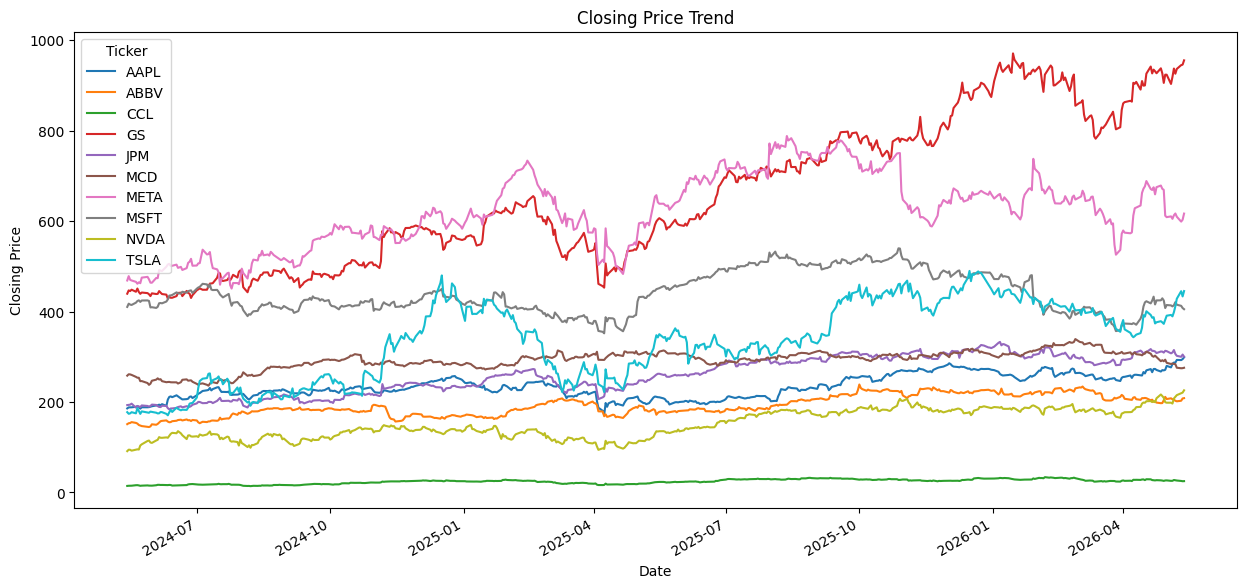

In [34]:
selected_tickers = company_tickers[:]

df['Close'][selected_tickers].plot(figsize=(15, 7))

plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

## 9. Daily Percentage Returns

Daily percentage returns are calculated from closing prices. Returns are better than raw prices for clustering because they compare relative movement rather than absolute stock price levels.


In [13]:
daily_returns = df['Close'].pct_change().dropna()
daily_returns[selected_tickers].head()

Ticker,AAPL,ABBV,CCL,GS,JPM,MCD,META,MSFT,NVDA
Date,,,,,,,,,
2024-05-15,0.012218,0.013615,0.023416,0.016621,0.002977,0.011860,0.020536,0.017484,0.035838
2024-05-16,0.000633,0.003419,0.002692,-0.003368,0.001781,-0.001314,-0.017257,-0.004940,-0.002864
2024-05-17,0.000158,0.012595,0.006711,0.006889,0.011458,-0.004132,-0.002789,-0.001853,-0.019924
2024-05-20,0.006162,-0.011177,0.072667,-0.010220,-0.044973,-0.016558,-0.006505,0.012208,0.024881
2024-05-21,0.006857,-0.009905,0.006837,0.016136,0.020145,-0.007466,-0.008980,0.008699,0.006394


## 10. Daily Returns Visualization

Daily returns are plotted to observe short-term fluctuations and volatility patterns among the selected stocks.


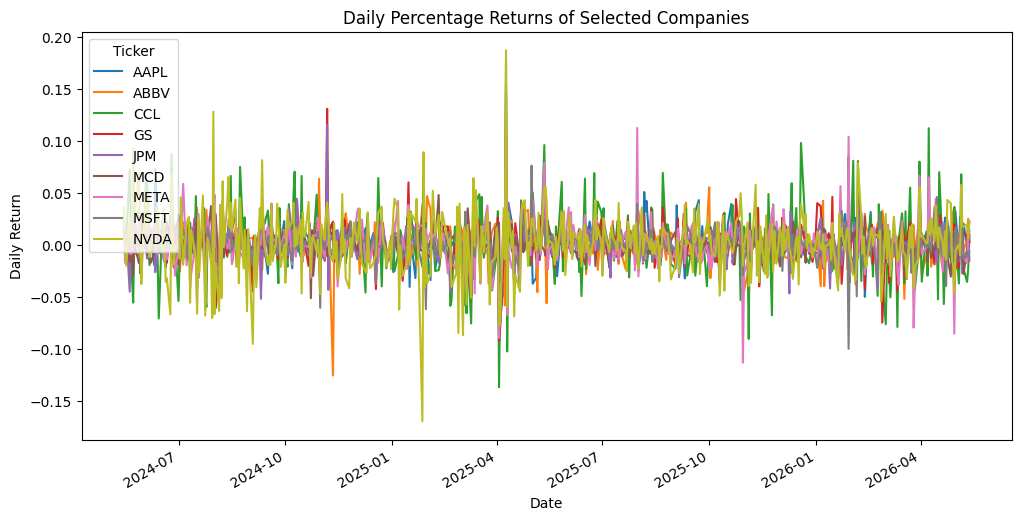

In [14]:
daily_returns[selected_tickers].plot(figsize=(12, 6))
plt.title("Daily Percentage Returns of Selected Companies")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

## 11. Volatility Analysis

Volatility is calculated using the standard deviation of daily returns. Stocks with higher volatility show larger return fluctuations and may behave differently from the rest of the group.


In [15]:
volatility = daily_returns.std().sort_values(ascending=False)
volatility.head(10)

,0
Ticker,
TSLA,0.038405
NVDA,0.030582
CCL,0.030470
META,0.022674
GS,0.019325
AAPL,0.017774
ABBV,0.016508
JPM,0.015929
MSFT,0.015554


## 12. Top Volatile Stocks

The most volatile stocks are visualized to identify which companies show the highest return variation. In the final result, this helps explain why TSLA is separated into its own cluster.


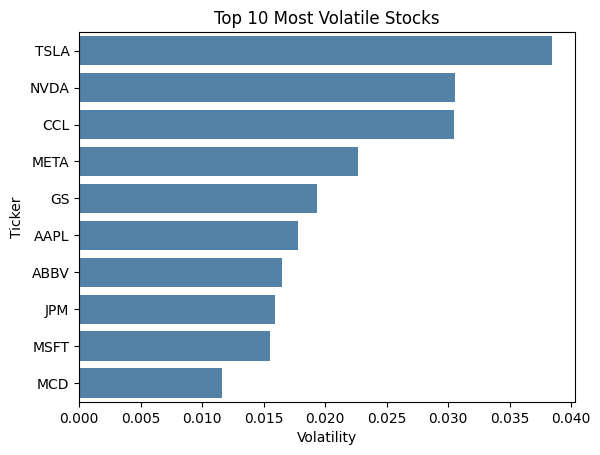

In [16]:
top_volatile = volatility.head(10)

sns.barplot(x=top_volatile.values, y=top_volatile.index, color="steelblue")
plt.title("Top 10 Most Volatile Stocks")
plt.xlabel("Volatility")
plt.ylabel("Ticker")
plt.show()

## 13. Correlation Matrix

The correlation matrix shows how closely the daily returns of different stocks move together. A high correlation means two stocks often move in the same direction, while a low correlation means their return behavior is different.


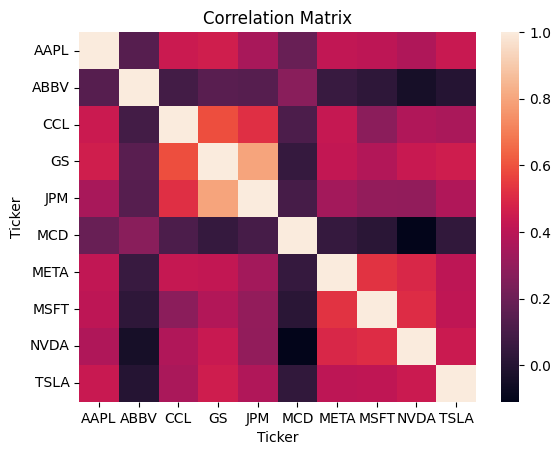

In [17]:
corr = daily_returns.corr()
sns.heatmap(corr)
plt.title("Correlation Matrix")
plt.show()

In [18]:
daily_returns = df['Close'].pct_change().dropna()
daily_returns.head()


Ticker,AAPL,ABBV,CCL,GS,JPM,MCD,META,MSFT,NVDA,TSLA
Date,,,,,,,,,,
2024-05-15,0.012218,0.013615,0.023416,0.016621,0.002977,0.011860,0.020536,0.017484,0.035838,-0.020051
2024-05-16,0.000633,0.003419,0.002692,-0.003368,0.001781,-0.001314,-0.017257,-0.004940,-0.002864,0.004885
2024-05-17,0.000158,0.012595,0.006711,0.006889,0.011458,-0.004132,-0.002789,-0.001853,-0.019924,0.014985
2024-05-20,0.006162,-0.011177,0.072667,-0.010220,-0.044973,-0.016558,-0.006505,0.012208,0.024881,-0.014144
2024-05-21,0.006857,-0.009905,0.006837,0.016136,0.020145,-0.007466,-0.008980,0.008699,0.006394,0.066591


## 14. Return Summary Statistics

Summary statistics such as mean, standard deviation, minimum, and maximum return are calculated. These values help identify stocks with unusual or highly volatile return behavior.


In [19]:
return_summary = daily_returns.describe().T
return_summary[["mean", "std", "min", "max"]].sort_values("std", ascending=False).head(10)


,mean,std,min,max
Ticker,,,,
TSLA,0.002567,0.038405,-0.154262,0.226900
NVDA,0.002280,0.030582,-0.169682,0.187227
CCL,0.001559,0.030470,-0.136863,0.174955
META,0.000804,0.022674,-0.113348,0.147556
GS,0.001740,0.019325,-0.092115,0.130978
AAPL,0.001107,0.017774,-0.092456,0.153289
ABBV,0.000783,0.016508,-0.125664,0.063605
JPM,0.001009,0.015929,-0.074838,0.115445
MSFT,0.000096,0.015554,-0.099931,0.101337


## 15. Feature Matrix Preparation

The return data is cleaned and converted into a machine learning matrix. Each stock becomes one data point, and its daily returns become the features used for clustering.


In [20]:
daily_movements_clean = daily_returns.dropna(axis=1)

valid_tickers = daily_movements_clean.columns

X = daily_movements_clean.to_numpy().T

X.shape

(10, 500)

## 16. Data Scaling

`StandardScaler` is applied before K-Means because K-Means is distance-based. Scaling ensures that stocks are compared fairly based on their return patterns.


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:3]

array([[-0.08918375,  0.37601621, -0.22815503, ..., -0.07611037,
         0.45264339,  0.38780057],
       [ 0.01180793,  0.83839163,  1.03192344, ...,  0.30678432,
         1.60626097, -0.45334517],
       [ 0.72042452,  0.71769227,  0.43581776, ..., -1.86288389,
        -1.518932  , -0.12679217]])

## 17. Selecting the Best Number of Clusters

Multiple K values are tested for K-Means. Two metrics are used:

- **Inertia**: Measures how compact the clusters are. It decreases as K increases, so it is mainly used with the elbow method.
- **Silhouette Score**: Measures how well-separated the clusters are. A higher score indicates better cluster separation.

The final K is selected using the highest silhouette score, with inertia used as supporting evidence.


In [22]:
k_range = range(2, min(11, len(valid_tickers)))

inertia_scores = []
silhouette_scores = []

for k in k_range:
    k_means = KMeans(
        init="k-means++",
        n_clusters=k,
        n_init=12,
        max_iter=1000,
        random_state=42
    )

    k_means.fit(X_scaled)

    labels = k_means.labels_

    inertia_scores.append(k_means.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]

print("Best k:", best_k)
print("Best silhouette score:", max(silhouette_scores))


Best k: 2
Best silhouette score: 0.26087341626624744


## 18. Elbow Method and Silhouette Score Visualization

The elbow plot and silhouette score plot are used to compare different K values visually. In this project, K = 2 gives the best silhouette score.


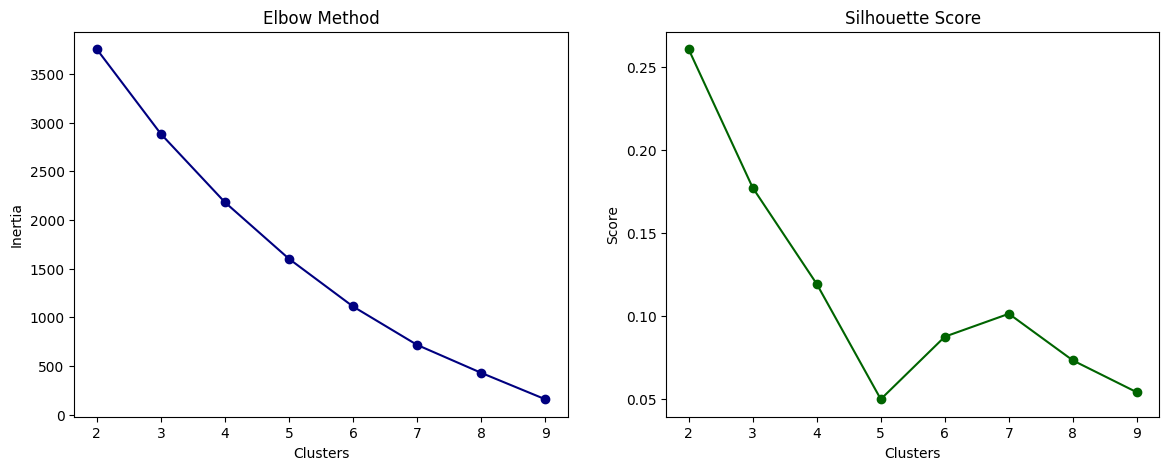

In [23]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.plot(k_range, inertia_scores, marker='o',color = "navy")

plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")


plt.subplot(1, 2, 2)

plt.plot(k_range, silhouette_scores, marker='o',color = "darkgreen")

plt.title("Silhouette Score")
plt.xlabel("Clusters")
plt.ylabel("Score")

plt.show()

## 19. Final K-Means Model

The final K-Means model is trained using the best K selected from the silhouette score. The resulting labels assign each stock to a cluster.


In [24]:
number_of_clusters = best_k

k_means_final = KMeans(
    init="k-means++",
    n_clusters=number_of_clusters,
    n_init=12,
    max_iter=1000,
    random_state=42
)

k_means_final.fit(X_scaled)

cluster_labels = k_means_final.labels_


## 20. Final Cluster Results

The cluster labels are combined with stock tickers to show which stocks belong to each cluster.


In [25]:
cluster_results = pd.DataFrame({
    "Ticker": valid_tickers,
    "Cluster": cluster_labels
})

cluster_results = cluster_results.sort_values(["Cluster", "Ticker"]).reset_index(drop=True)
cluster_results

,Ticker,Cluster
0,AAPL,0
1,ABBV,0
2,CCL,0
3,GS,0
4,JPM,0
5,MCD,0
6,META,0
7,MSFT,0
8,NVDA,0
9,TSLA,1


## 21. Cluster Composition

The stocks in each cluster are printed to make the clustering result easy to interpret.


In [26]:
for cluster in sorted(cluster_results["Cluster"].unique()):
    members = cluster_results.loc[cluster_results["Cluster"] == cluster, "Ticker"].tolist()
    print(f"Cluster {cluster}: {', '.join(members)}")

Cluster 0: AAPL, ABBV, CCL, GS, JPM, MCD, META, MSFT, NVDA
Cluster 1: TSLA


## 22. Cluster Size Distribution

The number of stocks in each cluster is visualized. The final model forms two clusters, where TSLA is separated as its own distinct cluster.


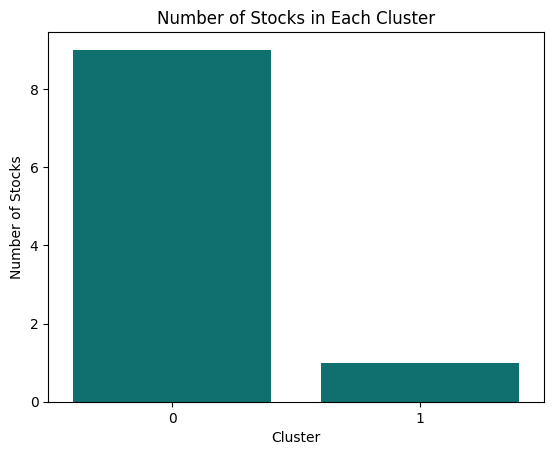

In [27]:
cluster_counts = cluster_results["Cluster"].value_counts().sort_index()

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, color="teal")
plt.title("Number of Stocks in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Stocks")
plt.show()

## 23. PCA for Visualization

Principal Component Analysis (PCA) reduces the high-dimensional return data into two dimensions. PCA is not used for clustering; it is used only to visualize the K-Means clusters in 2D.


In [28]:
pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": pca_components[:, 0],
    "PC2": pca_components[:, 1],
    "Ticker": valid_tickers,
    "Cluster": cluster_labels
})

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.27557501 0.18293528]


## 24. PCA Cluster Plot

The PCA scatter plot shows the final stock clusters. TSLA appears far from the remaining stocks, supporting the interpretation that it has a distinct return pattern.


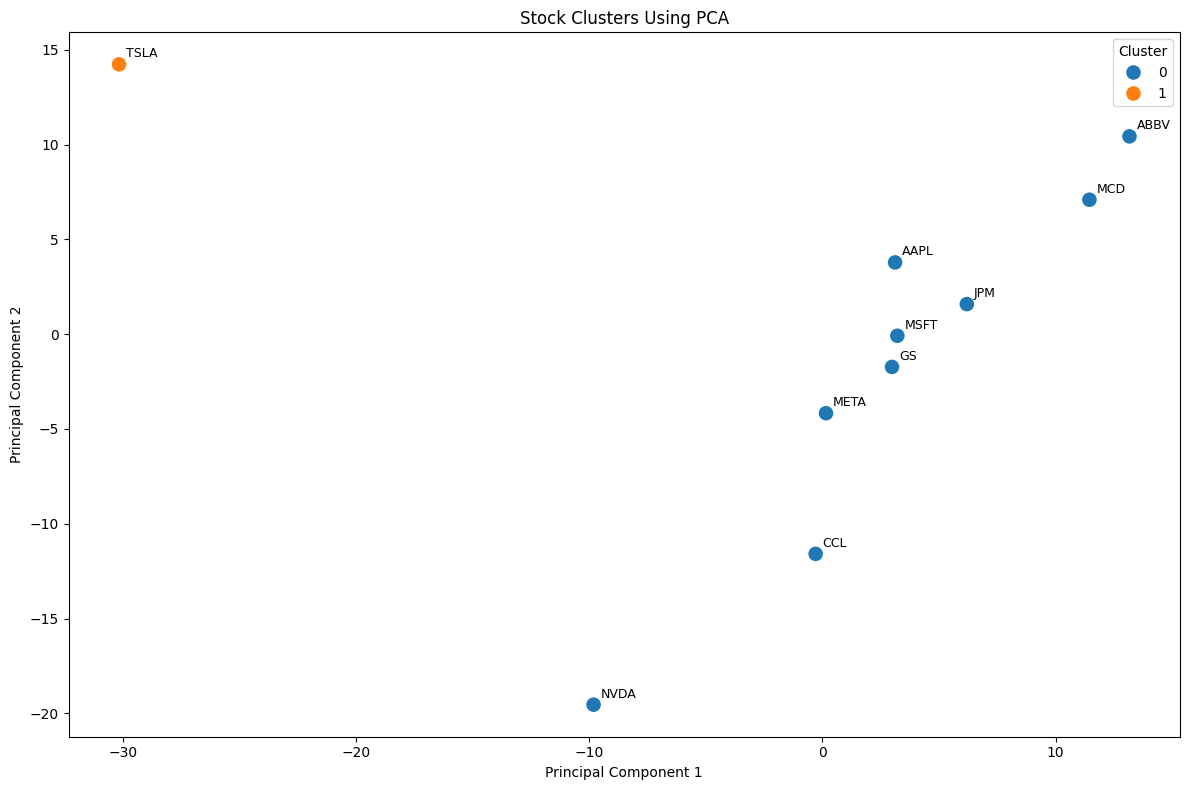

In [29]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=pca_df["Cluster"],
    palette="tab10",
    s=130,
    ax=ax
)

for i in range(len(pca_df)):
    ax.annotate(
        pca_df.loc[i, "Ticker"],
        (pca_df.loc[i, "PC1"], pca_df.loc[i, "PC2"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title("Stock Clusters Using PCA")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(title="Cluster")

plt.tight_layout()
plt.show()


## 25. Cluster Return Profile

The average daily return pattern is calculated for each cluster. This helps compare how the TSLA cluster behaves against the cluster containing the remaining stocks.


In [30]:
movement_by_company = daily_movements_clean.T.copy()
movement_by_company["Cluster"] = cluster_labels

cluster_movement_profile = movement_by_company.groupby("Cluster").mean().T
cluster_movement_profile.head()

Cluster,0,1
Date,,
2024-05-15 00:00:00,0.017174,-0.020051
2024-05-16 00:00:00,-0.002358,0.004885
2024-05-17 00:00:00,0.001013,0.014985
2024-05-20 00:00:00,0.002943,-0.014144
2024-05-21 00:00:00,0.004302,0.066591


## 26. Rolling Average Returns by Cluster

A 20-day rolling average return plot is used to compare cluster behavior over time. The TSLA cluster shows stronger fluctuations, which supports its separation as a high-volatility return pattern.


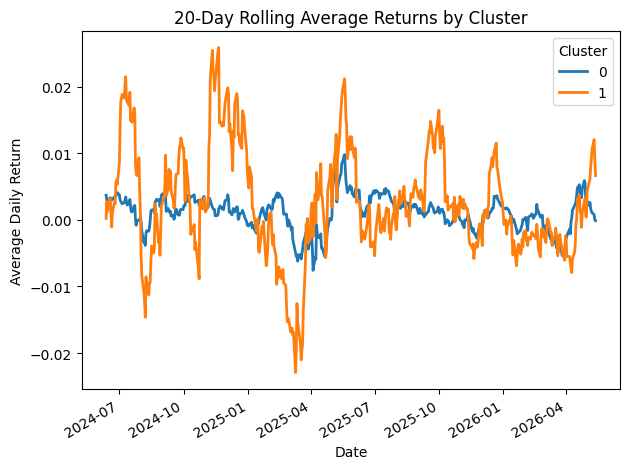

In [31]:
cluster_movement_profile.rolling(window=20).mean().plot(linewidth=2)
plt.title("20-Day Rolling Average Returns by Cluster")
plt.xlabel("Date")
plt.ylabel("Average Daily Return")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## Final Conclusion

This project demonstrates an experimental unsupervised learning workflow for stock market clustering. Historical data is extracted directly using `yfinance`, daily percentage returns are used as features, and K-Means clustering is applied after standard scaling.

The best number of clusters is selected using silhouette score, while inertia is analyzed through the elbow method. The final model selects K = 2 and identifies TSLA as a separate cluster because its return behavior and volatility are significantly different from the other selected stocks.

This result is acceptable because the model is not trying to create balanced sector-based groups. Instead, it is detecting distinct return behavior. In this case, TSLA behaves like a high-volatility outlier compared to the remaining stocks.

Key learnings from this project:

- Direct stock data extraction using `yfinance`
- Daily return-based feature engineering
- Volatility and correlation analysis
- K-Means clustering
- Inertia and elbow method interpretation
- Silhouette score-based K selection
- PCA-based cluster visualization
- Practical interpretation of an imbalanced but meaningful clustering result
